## OBJETIVO
Criar um modelo de aprendizado de máquina que prevê quem sobreviveu no Titanic

## HIPÓTESES
Pessoas com maior chances de sobrevivência:
- Pessoas da mesma família
- Mulheres
- Crianças
- Pessoas de maior renda / 1a. classe (Pclass)
- Funcionários do navio de alto escalão (capitão)

Pessoas com menor chances de sobrevivencia:
- Sozinhas
- Idosos
- Alocadas em alguma cabine/setor mais longe do bote salva vidas


### colunas incompletas
- Idade
- Cabine




In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Load file
filepath = r"C:\Users\marco\OneDrive\Documents\CS\Intern\PythonNotebook\bootcampia\ex_titanic\train.csv"
data_frame = pd.read_csv(filepath)

survivalList = r"C:\Users\marco\OneDrive\Documents\CS\Intern\PythonNotebook\bootcampia\ex_titanic\gender_submission.csv"
df_survivalList = pd.read_csv(survivalList)

In [4]:
data_frame.shape

(891, 12)

In [5]:
data_frame.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
data_frame.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
data_frame = data_frame.drop("PassengerId", axis=1)

In [8]:
# Survived Passengers in sample ( 414/891 )
df_survivedPassengers = data_frame[data_frame["Survived"] == 1]
df_survivedPassengers



,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [9]:
df_survivedWomen = data_frame[(data_frame["Survived"] == 1) & (data_frame["Sex"] == "female")]
df_survivedWomen

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
875,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S


In [10]:
df_survivedWomen.count()

Survived    233
Pclass      233
Name        233
Sex         233
Age         197
SibSp       233
Parch       233
Ticket      233
Fare        233
Cabin        91
Embarked    231
dtype: int64

<Axes: title={'center': 'Age'}, xlabel='Sex'>

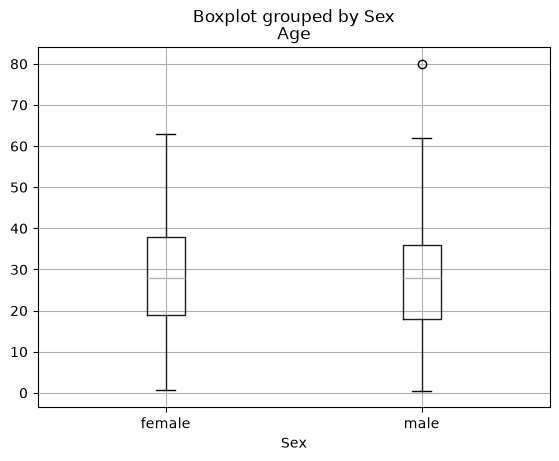

In [11]:
# Gráfico que mostra sobreviventes por gênero e idade

df_survivedPassengers.boxplot(by="Sex", column="Age")

# def plotar_scatter(Age):


In [12]:
df_survivedByPclass = data_frame.groupby("Pclass")["Survived"].mean()
df_survivedByPclass


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

1a. classe: 62,96%
2a. classe: 47,28%
3a. classe: 24,24% 


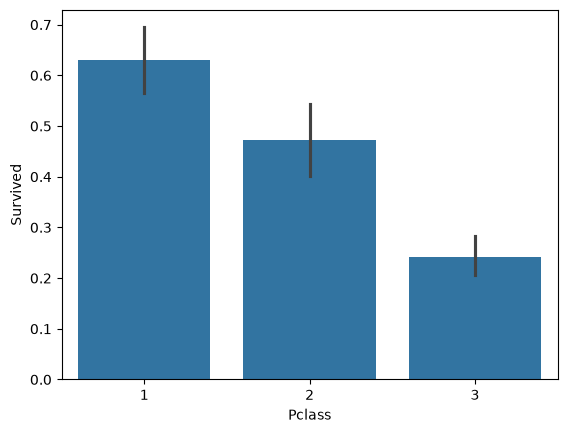

In [13]:
sns.barplot(
    data = data_frame,
    x="Pclass",
    y="Survived"
)

plt.show()

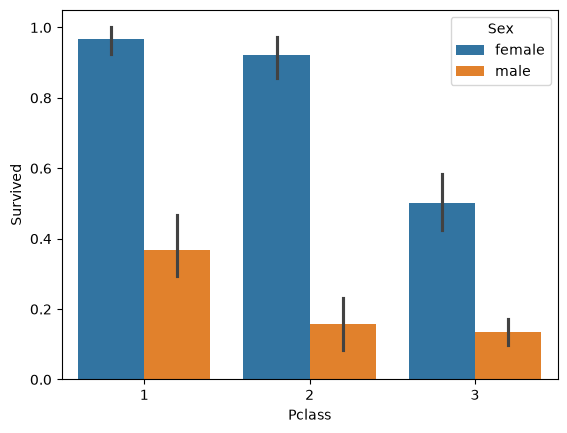

In [14]:
sns.barplot(
    data = data_frame,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.show()

Descobri que na coluna de nomes tenho os títulos Miss e Master e em sua grande maioria representa crianças, bebês, adolescentes e jovens.

Faz sentido, porque essas pessoas não são casadas ainda

In [15]:
# Crianças e jovens HOMENS 

df_master = data_frame[data_frame["Name"].str.contains("Master")]
df_master


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
16,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q
50,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S
59,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S
63,0,3,"Skoog, Master. Harald",male,4.00,3,2,347088,27.9000,NaN,S
65,1,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C
78,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
125,1,3,"Nicola-Yarred, Master. Elias",male,12.00,1,0,2651,11.2417,NaN,C
159,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
164,0,3,"Panula, Master. Eino Viljami",male,1.00,4,1,3101295,39.6875,NaN,S


In [36]:
medianMaster = df_master["Age"].median()
data_frame.loc[data_frame["Name"].str.contains("Master"), "Age"] = data_frame.loc[data_frame["Name"].str.contains("Master"), "Age"].fillna(medianMaster)


Crianças e Jovens Mulheres Pclass1

In [20]:
# Crianças e jovens MULHERES 

df_miss = data_frame[data_frame["Name"].str.contains("Miss")]


In [21]:
df_miss.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,182.000000,182.000000,146.000000,182.000000,182.000000,182.000000
mean,0.697802,2.307692,21.773973,0.714286,0.549451,43.797873
std,0.460477,0.849989,12.990292,1.431961,0.804184,66.027199
min,0.000000,1.000000,0.750000,0.000000,0.000000,6.750000
25%,0.000000,1.250000,14.125000,0.000000,0.000000,7.951050
50%,1.000000,3.000000,21.000000,0.000000,0.000000,15.620850
75%,1.000000,3.000000,30.000000,1.000000,1.000000,41.034400
max,1.000000,3.000000,63.000000,8.000000,2.000000,512.329200


O número de mulheres com esse título "Miss" é muito grande

Separar por Pclass, ver o boxplot e describe, se os valores ainda forem muito discrepantes ver outra variável para fazer a análise


In [22]:
df_missPclass1 = df_miss[df_miss["Pclass"] == 1]
df_missPclass1

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
61,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
88,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
136,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
177,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C49,C
195,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,B80,C
215,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C
218,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,76.2917,D15,C
257,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S
258,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C


In [23]:
df_missPclass1.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,46.000000,46.0,45.000000,46.000000,46.000000,46.000000
mean,0.956522,1.0,30.000000,0.391304,0.586957,124.402715
std,0.206185,0.0,12.852308,0.773973,0.858321,90.384256
min,0.000000,1.0,2.000000,0.000000,0.000000,26.283300
25%,1.000000,1.0,21.000000,0.000000,0.000000,76.708350
50%,1.000000,1.0,30.000000,0.000000,0.000000,91.750000
75%,1.000000,1.0,36.000000,0.750000,1.000000,151.550000
max,1.000000,1.0,63.000000,3.000000,2.000000,512.329200


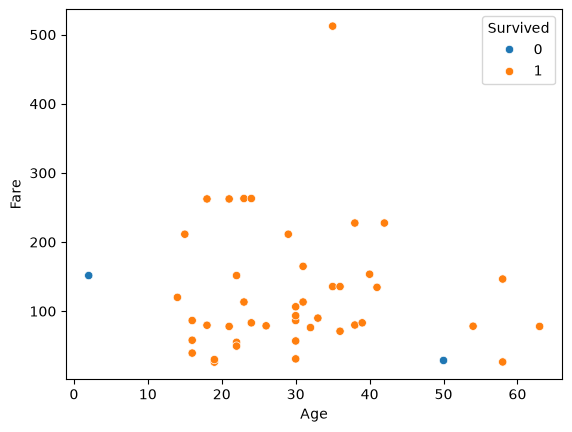

In [24]:
# Gráfico scatter

sns.scatterplot(
    data=df_missPclass1,
    x="Age",
    y="Fare",
    hue="Survived"
)
plt.show()

In [ ]:
medianPclass1 = df_missPclass1["Age"].median()

data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 1), "Age"] = data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 1), "Age"].fillna(medianPclass1)


Crianças e Jovens Mulheres Pclass2

In [27]:
df_missPclass2 = df_miss[df_miss["Pclass"] == 2]
df_missPclass2.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,34.000000,34.0,32.000000,34.000000,34.000000,34.000000
mean,0.941176,2.0,22.390625,0.264706,0.558824,20.393750
std,0.238833,0.0,13.374708,0.511019,0.785905,11.900908
min,0.000000,2.0,2.000000,0.000000,0.000000,10.500000
25%,1.000000,2.0,11.750000,0.000000,0.000000,13.000000
50%,1.000000,2.0,24.000000,0.000000,0.000000,13.000000
75%,1.000000,2.0,30.625000,0.000000,1.000000,26.187500
max,1.000000,2.0,50.000000,2.000000,2.000000,65.000000


In [ ]:
medianPclass2 = df_missPclass2["Age"].median()

data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 2), "Age"] = data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 2), "Age"].fillna(medianPclass2)


C:\Users\marco\AppData\Local\Temp\ipykernel_8272\3289159008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missPclass2["Age"] = df_missPclass2["Age"].fillna(median)


Crianças e Jovens Mulheres Pclass3

In [30]:
df_missPclass3 = df_miss[df_miss["Pclass"] == 3]
df_missPclass3.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,102.000000,102.0,69.000000,102.000000,102.000000,102.000000
mean,0.500000,3.0,16.123188,1.009804,0.529412,15.248043
std,0.502469,0.0,9.697315,1.765988,0.792363,12.649688
min,0.000000,3.0,0.750000,0.000000,0.000000,6.750000
25%,0.000000,3.0,9.000000,0.000000,0.000000,7.750000
50%,0.500000,3.0,18.000000,0.000000,0.000000,8.756250
75%,1.000000,3.0,22.000000,1.000000,1.000000,19.258300
max,1.000000,3.0,45.000000,8.000000,2.000000,69.550000


In [37]:
medianPclass3 = df_missPclass3["Age"].median()

data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 3), "Age"] = data_frame.loc[(data_frame["Name"].str.contains("Miss")) & (data_frame["Pclass"] == 3), "Age"].fillna(medianPclass3)


In [38]:
data_frame.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         139
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [ ]:
## 